## Lifecycle of a Data Science Projects

  1. Data Collection Statergy---from company side,3rd party APi's,Surveys,Surveys
  2. Feature Engineering---Handling Missing Values
Why are their Missing values?? Survey--Depression Survey

They hesitate to put down the information
Survey informations are not that valid
Men--salary
Women---age
People may have died----NAN
Data Science Projects---Dataset should be collected from multiple sources

### What are the different types of Missing Data?
Missing Completely at Random, MCAR:
A variable is missing completely at random (MCAR) if the probability of being missing is the same for all the observations. When data is MCAR, there is absolutely no relationship between the data missing and any other values, observed or missing, within the dataset. In other words, those missing data points are a random subset of the data. There is nothing systematic going on that makes some data more likely to be missing than other.

### Meaning: 
The probability a value is missing does not depend on the value itself or on any other variables. Missingness is pure random noise.

### Example: 
A sensor reading is lost because of a random network glitch unrelated to the sensor value or any user attribute.

### Implication: 
Listwise deletion or simple imputation is unbiased (statistically safe).

In [1]:
import numpy as np
import pandas as pd

In [2]:
df= pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


## 2. Missing Data Not At Random(MNAR): Systematic missing Values
There is absolutely some relationship between the data missing and any other values, observed or missing, within the dataset.

### Meaning: 
Missingness depends on the unobserved/missing value itself, even after considering observed data.

### Example: 
People with very high income are less likely to report income (so the chance of missing depends on the income itself).

### Implication: 
Hard problem — naive imputation can be biased. You need domain knowledge, sensitivity analysis, or models that explicitly model missingness.

In [8]:
# From above dataset, both Cabin and Age are MNAR, we will apply condition and replace NaN values with 1 or 0 like

df['cabin_null']= np.where(df['Cabin'].isnull(),1,0)

# Find the percentage of the NaN values inside cabin_null column
df['cabin_null'].mean()

np.float64(0.7710437710437711)

In [11]:
# Now we'll check how many survived people having non missing values from cabin_null column

df.groupby(['Survived'])['cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: cabin_null, dtype: float64

#### Above results shows that Not Survived are 86% having missing values and Survived are 60% having missing values

## 3. Missing at Random (MAR): 

### Meaning: 
Missingness depends on observed variables but not on the missing value itself (after conditioning on observed data).

### Example: 
Income is missing more often for younger respondents, but among people of the same age group the missingness doesn’t depend on income value.

### Implication: 
Imputation using models that use other observed features (regression or multivariate methods) is appropriate.

Men: Hide their Salary
Women: Hide their Age

# All the Techniques having Missing Values:
   1. Mean/ Median/ Mode replacement
   2. Random Sample Imputation
   3. Capturing NaN values with the new Feature(vv Imp)
   4. End of Distribution Imputation
   5. Arbitrary Imputation
   6. Frequent Categories Imputation

## 1. Mean/Median/Mode Replacement:
#### when should we apply that?
        Mean/Median imputation has the assumption that data are missing completely random (MCAR).
        We solve this by replacing the most frequent occurance of variables.

In [13]:
df= pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
# let's go and see the percentage of missing values
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

#### The above results shows that we only have missing values in Age column. So we will apply
#### the mean imputation on Age column.

In [17]:
def impute_nan(df,variable,median):
    df[variable+'_median']= df[variable].fillna(median)

median= df.Age.median()
median



np.float64(28.0)

In [20]:
impute_nan(df, 'Age', median)

df.head()

,Survived,Age,Fare,Agemedian,Age_median
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


In [24]:
#Now I will check how much std varies in Original Age column and newly created column after imputation
print(df['Age'].std())
print(df['Age_median'].std())

#minor difference is noticed below and we will plot this in next step

14.526497332334042
13.019696550973201


In [25]:
import matplotlib.pyplot as plt
%matplotlib inline

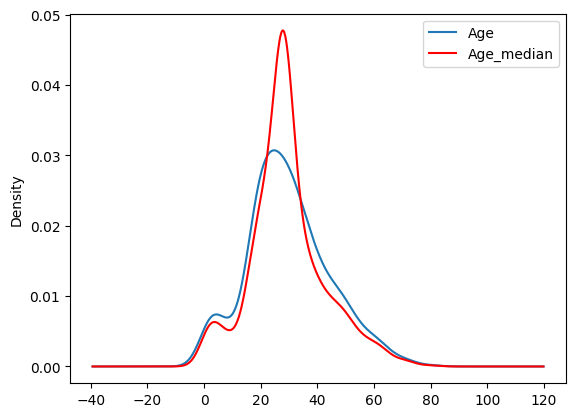

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind='kde', ax=ax)
df.Age_median.plot(kind='kde', ax=ax, color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

## Advantages And Disadvantages of Mean/Median Imputation
### Advantages
1. Easy to implement(Robust to outliers) means not easily affected by extreme outliers
2. Faster way to obtain the complete dataset
### Disadvantages
1. Change or Distortion in the original variance
2. Impacts Correlation

# Random Sample Imputation
    Aim: Random sample imputation consists of taking random observation from the dataset and we use this observation to replace the nan values

    When should it be used? It assumes that the data are missing completely at random(MCAR)

In [27]:
df=pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [29]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [31]:
# will see the mean of the missing values
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [35]:
df['Age'].isnull().sum()

np.int64(177)

In [44]:
# I dropped the NaN values bcz, from remaining values I have to pickup the sample values
# Now I will pick the random sample value from the Age column that is 177 (df['Age'].isnull().sum())
# it will randomly select the sample value each time you run this line of code without random_state=0 else it will update each time you run the code
# and insert/putting those random values to the NaN values
df['Age'].dropna().sample(df['Age'].isnull().sum(), random_state=0)

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [45]:
df[df['Age'].isnull()].index

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [59]:
def impute_nan(df,variable,median):
    # Mean/Median imputation
    df[variable+'_median']= df[variable].fillna(median) 
    # the below line simply copying the feature value to the newly created feature_random column
    df[variable+'_random']= df[variable]
    # it will have the random sample to fill the NaN values
    random_sample= df[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index to merge the dataset
    random_sample.index= df[df[variable].isnull()].index
    # I will merge those values
    # whereever it is null with feature name Age_random, it will replace with random_sample
    df.loc[df[variable].isnull(), variable+'_random']= random_sample

In [60]:
median= df.Age.median()
median

np.float64(28.0)

In [61]:
impute_nan(df,'Age',median)

In [62]:
df.head()

,Survived,Age,Fare,Age_median,Age_random
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


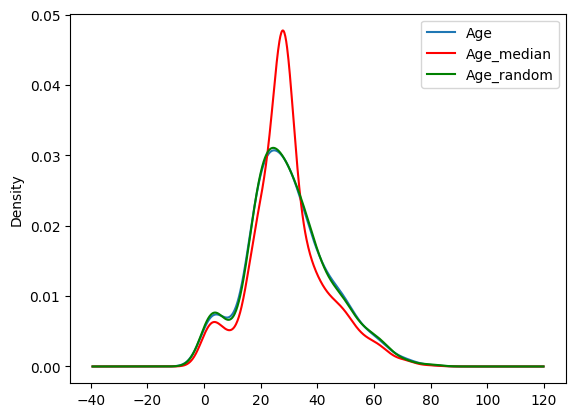

In [67]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind='kde', ax=ax)
df.Age_median.plot(kind='kde', ax=ax, color='red')
df.Age_random.plot(kind='kde', ax=ax, color='green')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

## Advantages

  Easy to Implement.
  No distortion in variance
## Disadvantage:
  In every situation, randomness won't work.

 # 3. Capturing NaN values with new feature or variable
      This scenario works well if the data are not missing completely at random MNCAR.

In [68]:
df= pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [69]:
df['Age_NaN']= np.where(df['Age'].isnull(),1,0)
df.head()

,Survived,Age,Fare,Age_NaN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0


In [72]:
df.Age.mean()
df['Age'].fillna(df.Age.median(), inplace=True)
df.head(30)

# Now wherever the value is 1 is Age_NaN column is replaced the value with median 28 in Age column

C:\Users\Talha\AppData\Local\Temp\ipykernel_30608\875379880.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df.Age.median(), inplace=True)


,Survived,Age,Fare,Age_NaN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0
5,0,28.0,8.4583,1
6,0,54.0,51.8625,0
7,0,2.0,21.0750,0
8,1,27.0,11.1333,0
9,1,14.0,30.0708,0


# Advantages
  1. Easy to Implement.
  2. Captures the importance of missing values even the missing value is replaced by mean/median with the help of Age_NaN feature column.
# Disadvantages
  1. Only one disadvantage is, if 100 features are having NaN or missing values then 100 other additional features are created that will lead to Curse      of Dimentionality.

# 4. End of Distribution Imputation
     I have to pickup the right end of the distribution of the data.

In [73]:
df= pd.read_csv('titanic.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


<Axes: >

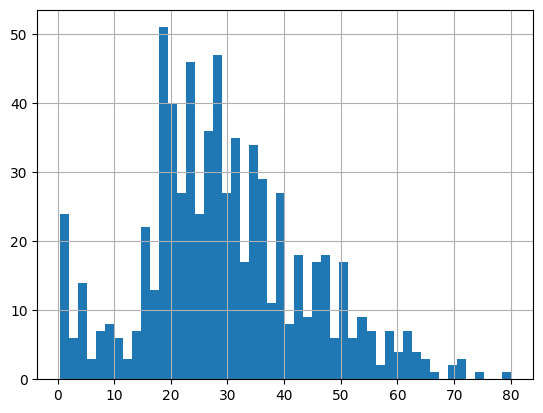

In [76]:
df.Age.hist(bins=50)

In [82]:
extreme= df.Age.mean()+3*df.Age.std()

In [83]:
import seaborn as sns


<Axes: xlabel='Age'>

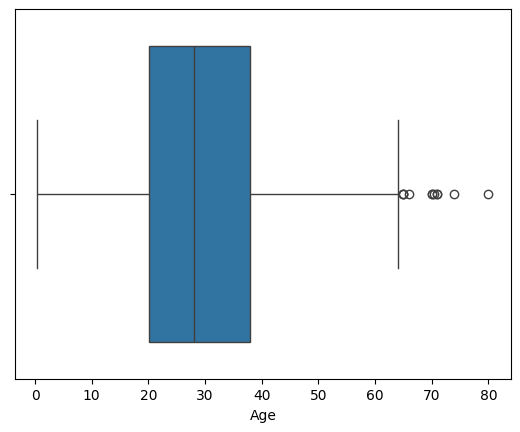

In [84]:
sns.boxplot(x='Age',data=df)

In [85]:
def impute_nan(df,variable,median,extreme):
    #create column Age_end_distribution and replace each empty value with end distribution/outliers
    df[variable+'_end_distribution']= df[variable].fillna(extreme)
    df[variable].fillna(median,inplace=True)
    

In [86]:
impute_nan(df,'Age',df.Age.median(),extreme)

C:\Users\Talha\AppData\Local\Temp\ipykernel_30608\1805064120.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[variable].fillna(median,inplace=True)


In [87]:
df.head()

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0
